In [1]:
pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:


import mysql.connector

mydb=mysql.connector.connect(user='root',password='Student123@',host='localhost')


In [3]:
mycursor=mydb.cursor()
mycursor.execute("SHOW DATABASES")

for x in mycursor:
    print(x)

('4schema',)
('information_schema',)
('mysql',)
('new_schema',)
('new_schema1',)
('newschema',)
('performance_schema',)
('sys',)
('university',)
('week3',)
('week4',)


cnx=mysql.connector.connect(user='root',password='Student123@',host='localhost',database='week4')

mycursor=cnx.cursor()
mycursor.execute("select * from student")

for x in mycursor:
    print(x)

## Write an SQL query to display the names and salaries for those teachers whose salaries are less than or greater than the average salary. 

In [13]:
mycursor.execute('''select teacher.TEACHERSALARY,teacher.TEACHERNAME from teacher
where teacher.TEACHERSALARY<(select avg(teacher.TEACHERSALARY)from teacher) or  
teacher.TEACHERSALARY>(select avg(teacher.TEACHERSALARY)from teacher)''')
result = mycursor.fetchall()
print(result)

[(200000, 'WASIM AKRAM'), (250000, 'IMRAN KHAN'), (230000, 'KAPEL DEV'), (100000, 'SHAKIB UL HASSAN'), (150000, 'LARNCE KLUSNER'), (130000, 'BEN STOKES'), (120000, 'DALE STAYN'), (160000, 'GLENN MCGRATH')]


### Write and SQL query to display the unit’s name and its offering date as semester-YY. For example, if Databases unit is offered in Spring semester of year 2020, it should be displayed as below: DATABASES  SPRING-20 

In [20]:
mycursor.execute('''select unit.UNITNAME,CONCAT(enrolment.SEMESTER,
' ',RIGHT(enrolment.studyyear, 2)) as date 
from enrolment join unit using(unitcode)''')
result = mycursor.fetchall()
for resultvalue in result:
    print(resultvalue)


('PROGRAMMING', 'SPRING 20')
('PROGRAMMING', 'FALL 22')
('DATABASES', 'SPRING 20')
('DATABASES', 'WINTER 14')
('MATHEMATICS', 'SPRING 00')
('DATA SCIENCE', 'WINTER 19')
('DATA SCIENCE', 'FALL 17')
('MACHINE LEARNING', 'FALL 10')
('MACHINE LEARNING', 'SPRING 21')
('BUSSINES ANALYTICS', 'FALL 15')
('ADAVANCED DATABASES', 'WINTER 20')


### Write a Python script to display the unit’s names taught by professors or teachers whose names end with N. 

In [19]:
mycursor.execute("select unit.UNITNAME as val from unit join workload using (unitcode) join teacher using(teacherid) where TEACHERNAME like '%n'")
result = mycursor.fetchall()
for resultvalue in result:
    print(resultvalue[0])


DATA SCIENCE
MATHEMATICS
BUSSINES ANALYTICS
DATABASES


In [22]:
import pandas as pd 
cursor = cnx.cursor() 
cursor.execute("select * from STUDENT ") 
rows = cursor.fetchall() 
print("***** query output presented as a Python list *****") 
print("\n") 
for row in rows: 
    print(row)  
print("\n\n") 
print("***** query output presented as a pands dataframe *****") 
print("\n") 
df = pd.read_sql_query("select * from STUDENT ", cnx) 
print(df)     

***** query output presented as a Python list *****


('S001', 'MICHAEL BEVAN', datetime.date(1960, 9, 15), Decimal('3.20'), 'CHATSWOOD')
('S002', 'BRIAN LARA', datetime.date(1965, 2, 10), Decimal('4.00'), 'MARSFIELD')
('S003', 'VIVAN RICHARDS', datetime.date(1958, 11, 12), Decimal('4.50'), 'BURWOOD')
('S004', 'JAVED MIANDAD', datetime.date(1966, 5, 5), Decimal('3.50'), 'RYDE')
('S005', 'VIRAT KOHLI', datetime.date(1988, 10, 15), Decimal('4.30'), 'AUBURN')
('S006', 'BABAR AZAM', datetime.date(1991, 4, 20), Decimal('4.20'), 'LAKEMBA')
('S007', 'KUMAR SANGAKARA', datetime.date(1980, 1, 26), Decimal('3.70'), 'REDFERN')



***** query output presented as a pands dataframe *****


  STUDENTID      STUDENTNAME  STUDENTDOB  STUDENTGPA STUDENTSUBURB
0      S001    MICHAEL BEVAN  1960-09-15         3.2     CHATSWOOD
1      S002       BRIAN LARA  1965-02-10         4.0     MARSFIELD
2      S003   VIVAN RICHARDS  1958-11-12         4.5       BURWOOD
3      S004    JAVED MIANDAD  1966-05-05       

C:\Users\JhonJairoPABONGAMAS\AppData\Local\Temp\ipykernel_22832\2647798083.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("select * from STUDENT ", cnx)


In [23]:
teachersData=pd.read_sql_query("select teacher.TEACHERSALARY from teacher",cnx)
print(teachersData)

   TEACHERSALARY
0         200000
1         250000
2         230000
3         100000
4         150000
5         130000
6         120000
7         160000


C:\Users\JhonJairoPABONGAMAS\AppData\Local\Temp\ipykernel_22832\2159056408.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  teachersData=pd.read_sql_query("select teacher.TEACHERSALARY from teacher",cnx)


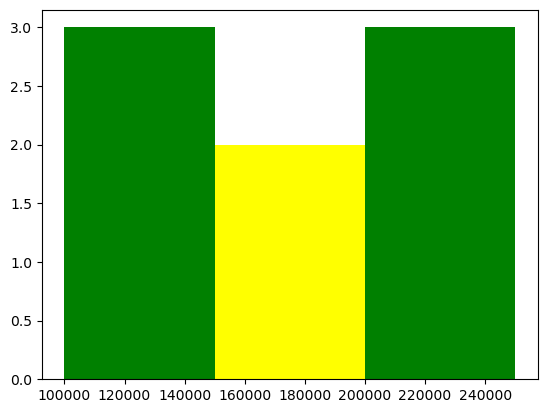

In [38]:
import matplotlib.pyplot as plt
n,bins,patches=plt.hist(teachersData['TEACHERSALARY'],bins = [100000, 150000, 200000, 
250000],color='red')
colors=['green','yellow','green']
for patch,color in zip(patches,colors):
    patch.set_facecolor(color)
plt.show()

In [45]:
teachersSalary=pd.read_sql_query("select  sum(teacher.TEACHERSALARY) as TEACHERSALARY,TEACHERDESIGNATION from teacher group by teacher.TEACHERDESIGNATION",cnx)
print(teachersSalary)

   TEACHERSALARY   TEACHERDESIGNATION
0       360000.0  ASSOCIATE PROFESSOR
1       480000.0            PROFESSOR
2       230000.0             LECTURER
3       150000.0            ASSOCIATE
4       120000.0      SENIOR LECTURER


C:\Users\JhonJairoPABONGAMAS\AppData\Local\Temp\ipykernel_22832\1390010408.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  teachersSalary=pd.read_sql_query("select  sum(teacher.TEACHERSALARY) as TEACHERSALARY,TEACHERDESIGNATION from teacher group by teacher.TEACHERDESIGNATION",cnx)


<Axes: title={'center': 'TEACHERSALARY'}, xlabel='TEACHERDESIGNATION'>

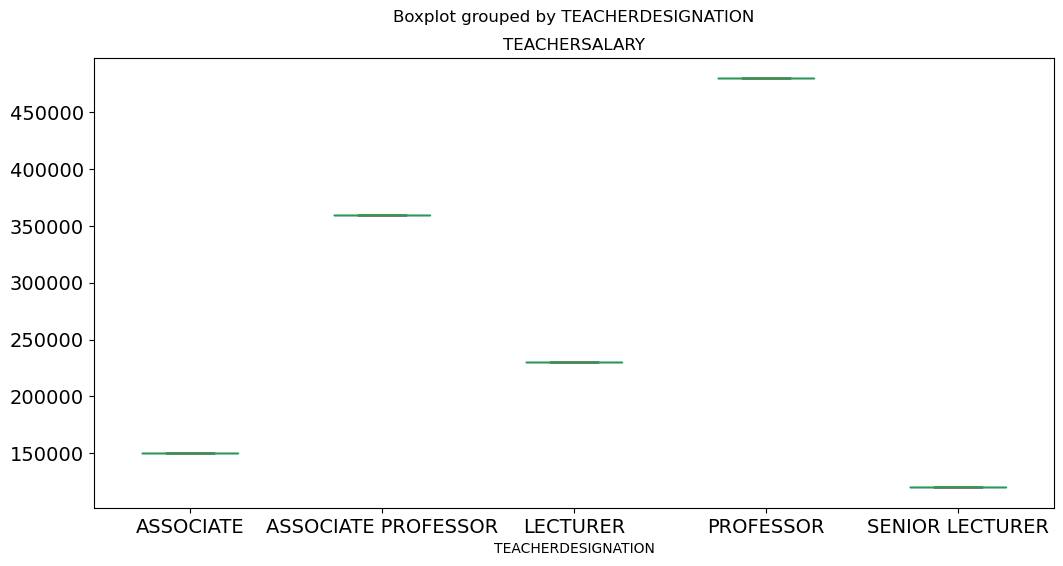

In [46]:
teachersSalary.boxplot(by ='TEACHERDESIGNATION', column=['TEACHERSALARY'], grid = 
False, figsize=(12,6), fontsize=14) 

In [48]:
creditsAndStudent=pd.read_sql_query("select distinct sum(unit.UNITCREDITPOINTS) as TOTAL_CREDITS,student.STUDENTNAME from student join enrolment using(studentid) join unit using(unitcode) group by STUDENTNAME",cnx)
print(creditsAndStudent)

   TOTAL_CREDITS      STUDENTNAME
0           10.0    MICHAEL BEVAN
1            3.0       BRIAN LARA
2            6.0   VIVAN RICHARDS
3            6.0    JAVED MIANDAD
4            2.0      VIRAT KOHLI
5            3.0       BABAR AZAM
6            3.0  KUMAR SANGAKARA


C:\Users\JhonJairoPABONGAMAS\AppData\Local\Temp\ipykernel_22832\2551007374.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  creditsAndStudent=pd.read_sql_query("select distinct sum(unit.UNITCREDITPOINTS) as TOTAL_CREDITS,student.STUDENTNAME from student join enrolment using(studentid) join unit using(unitcode) group by STUDENTNAME",cnx)


In [50]:
print(creditsAndStudent[creditsAndStudent.TOTAL_CREDITS == creditsAndStudent.TOTAL_CREDITS.max()]) 

   TOTAL_CREDITS    STUDENTNAME
0           10.0  MICHAEL BEVAN


In [53]:
df1 = pd.read_sql_query("SELECT distinct T.TEACHERID, TEACHERNAME FROM TEACHER T, WORKLOAD W WHERE T.TEACHERID= W.TEACHERID AND SCHEDULEHOURS = 3.5 ", cnx) 
print("***** Output for version 1 *****") 
print(df1)  
df2 = pd.read_sql_query("SELECT distinct T.TEACHERID, TEACHERNAME FROM TEACHER T, WORKLOAD W WHERE (T.TEACHERID, SCHEDULEHOURS) = (W.TEACHERID, 3.5) ", cnx) 

print("\n") 
print("***** Output for version 2 *****") 
print(df2)  
cnx.close() 

***** Output for version 1 *****
  TEACHERID       TEACHERNAME
0      T001       WASIM AKRAM
1      T004  SHAKIB UL HASSAN
2      T006        BEN STOKES


***** Output for version 2 *****
  TEACHERID       TEACHERNAME
0      T001       WASIM AKRAM
1      T004  SHAKIB UL HASSAN
2      T006        BEN STOKES


C:\Users\JhonJairoPABONGAMAS\AppData\Local\Temp\ipykernel_22832\196831628.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query("SELECT distinct T.TEACHERID, TEACHERNAME FROM TEACHER T, WORKLOAD W WHERE T.TEACHERID= W.TEACHERID AND SCHEDULEHOURS = 3.5 ", cnx)
C:\Users\JhonJairoPABONGAMAS\AppData\Local\Temp\ipykernel_22832\196831628.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql_query("SELECT distinct T.TEACHERID, TEACHERNAME FROM TEACHER T, WORKLOAD W WHERE (T.TEACHERID, SCHEDULEHOURS) = (W.TEACHERID, 3.5) ", cnx)
